# 05 - Time Series Feature Engineering

**Purpose:** create the modeling table for one-month-ahead community-attention forecasting.

Each row is a business at feature month `t`. The table supports two targets:

- regression: review count in month `t + 1`;
- classification: whether month `t + 1` is an attention pulse.

The features combine time-series history, business metadata, social exposure, and lightweight NLP signals from recent review text. January 2022 is excluded because it is incomplete.

In [1]:
from pathlib import Path
import json
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim" / "new_orleans"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "feature_engineering"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BUSINESSES_PATH = INTERIM_DIR / "businesses.jsonl"
REVIEWS_PATH = INTERIM_DIR / "reviews.jsonl"
USER_NETWORK_FEATURES_PATH = PROCESSED_DIR / "user_network_features.csv"
FORECASTING_DATASET_PATH = PROCESSED_DIR / "forecasting_dataset.csv"
COHORT_BUSINESSES_PATH = PROCESSED_DIR / "forecasting_cohort_businesses.csv"
FEATURE_SUMMARY_PATH = PROCESSED_DIR / "forecasting_feature_summary.json"

MIN_TOTAL_REVIEWS = 100
MIN_ACTIVE_MONTHS = 36
MODELING_START = pd.Period("2015-01", freq="M")
MODELING_END_FEATURE = pd.Period("2021-11", freq="M")
EXCLUDED_PARTIAL_MONTH = "2022-01"

PULSE_MIN_TARGET_REVIEWS = 3
PULSE_ABSOLUTE_LIFT = 2
PULSE_RELATIVE_LIFT = 1.5
RECENT_TEXT_WINDOW_MONTHS = 3

pd.set_option("display.max_columns", 120)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
print(PROJECT_ROOT)

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp


In [2]:
def iter_jsonl(path):
    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                yield json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON in {path} at line {line_number}") from exc

def has_category(categories, keywords):
    text = str(categories).lower()
    return int(any(keyword in text for keyword in keywords))

POSITIVE_WORDS = {
    "amazing", "awesome", "best", "delicious", "excellent", "favorite", "friendly", "fresh",
    "great", "happy", "love", "loved", "perfect", "recommend", "recommended", "tasty",
    "wonderful",
}
NEGATIVE_WORDS = {
    "awful", "bad", "bland", "cold", "disappointed", "disappointing", "dirty", "horrible",
    "overpriced", "poor", "rude", "slow", "terrible", "unfriendly", "worst",
}
POSITIVE_PATTERN = re.compile(r"\b(" + "|".join(sorted(POSITIVE_WORDS)) + r")\b", flags=re.IGNORECASE)
NEGATIVE_PATTERN = re.compile(r"\b(" + "|".join(sorted(NEGATIVE_WORDS)) + r")\b", flags=re.IGNORECASE)

def count_matches(text, pattern):
    return len(pattern.findall(str(text)))

In [3]:
businesses = pd.DataFrame([
    {
        "business_id": r["business_id"],
        "name": r.get("name"),
        "business_stars": r.get("stars"),
        "business_review_count": r.get("review_count"),
        "categories": r.get("categories") or "",
    }
    for r in iter_jsonl(BUSINESSES_PATH)
])

review_rows = []
for r in iter_jsonl(REVIEWS_PATH):
    review_rows.append({
        "review_id": r["review_id"],
        "business_id": r["business_id"],
        "user_id": r["user_id"],
        "stars": float(r["stars"]),
        "date": r["date"],
        "text": r.get("text") or "",
    })
reviews = pd.DataFrame(review_rows)
reviews["date"] = pd.to_datetime(reviews["date"])
reviews["month"] = reviews["date"].dt.to_period("M")
reviews = reviews[reviews["month"].astype(str) != EXCLUDED_PARTIAL_MONTH].copy()

print("businesses", businesses.shape)
print("reviews", reviews.shape, reviews["month"].min(), reviews["month"].max())

businesses (6215, 5)
reviews (633299, 7) 2005-03 2021-12


In [4]:
monthly_counts = reviews.groupby(["business_id", "month"]).size().rename("monthly_review_count").reset_index()
business_activity = monthly_counts.groupby("business_id").agg(total_reviews=("monthly_review_count", "sum"), active_months=("month", "nunique")).reset_index()

cohort = business_activity[(business_activity["total_reviews"] >= MIN_TOTAL_REVIEWS) & (business_activity["active_months"] >= MIN_ACTIVE_MONTHS)].copy()
cohort = cohort.merge(businesses, on="business_id", how="left")
cohort.to_csv(COHORT_BUSINESSES_PATH, index=False)
cohort_ids = cohort["business_id"].tolist()

print(f"Forecasting cohort businesses: {len(cohort_ids):,}")
cohort[["business_id", "name", "total_reviews", "active_months"]].head()

Forecasting cohort businesses: 1,151


,business_id,name,total_reviews,active_months
0,-1XSzguS6XLN-V6MVZMg2A,Restaurant Rebirth,528,71
1,-9ZNA22YhFlvTdLDYjvNdA,Cathedral-Basilica of St. Louis King of France,202,100
2,-A2OLubXDsMRPNN7LqohPA,Rollin Fatties,176,65
3,-AaxZJ_I4rSFOBJbBz4SlQ,Hansen's Sno-Bliz,519,125
4,-HUDQ5eek6Edz3zuNrE4jw,Staybridge Suites New Orleans French Qtr/Dwtn,116,71


In [5]:
all_months = pd.period_range(reviews["month"].min(), pd.Period("2021-12", freq="M"), freq="M")
index = pd.MultiIndex.from_product([cohort_ids, all_months], names=["business_id", "feature_month"])
panel = pd.DataFrame(index=index).reset_index()

monthly_star_stats = (
    reviews[reviews["business_id"].isin(cohort_ids)]
    .groupby(["business_id", "month"])
    .agg(monthly_review_count=("review_id", "size"), monthly_star_sum=("stars", "sum"))
    .reset_index()
    .rename(columns={"month": "feature_month"})
)

panel = panel.merge(monthly_star_stats, on=["business_id", "feature_month"], how="left")
panel["monthly_review_count"] = panel["monthly_review_count"].fillna(0).astype(int)
panel["monthly_star_sum"] = panel["monthly_star_sum"].fillna(0.0)
panel = panel.sort_values(["business_id", "feature_month"])

by_business = panel.groupby("business_id", group_keys=False)
panel["prev_month_reviews"] = panel["monthly_review_count"]
panel["rolling_3_avg"] = by_business["monthly_review_count"].rolling(3, min_periods=1).mean().reset_index(level=0, drop=True)
panel["rolling_6_avg"] = by_business["monthly_review_count"].rolling(6, min_periods=1).mean().reset_index(level=0, drop=True)
panel["same_month_previous_year"] = by_business["monthly_review_count"].shift(12).fillna(0)
panel["cumulative_review_count"] = by_business["monthly_review_count"].cumsum()
panel["cumulative_star_sum"] = by_business["monthly_star_sum"].cumsum()
panel["avg_rating_history"] = np.where(panel["cumulative_review_count"] > 0, panel["cumulative_star_sum"] / panel["cumulative_review_count"], 0.0)
panel["target_next_month_reviews"] = by_business["monthly_review_count"].shift(-1)
panel["target_month"] = panel["feature_month"] + 1
panel.head()

,business_id,feature_month,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,target_next_month_reviews,target_month
0,-1XSzguS6XLN-V6MVZMg2A,2005-03,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-04
1,-1XSzguS6XLN-V6MVZMg2A,2005-04,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-05
2,-1XSzguS6XLN-V6MVZMg2A,2005-05,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-06
3,-1XSzguS6XLN-V6MVZMg2A,2005-06,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-07
4,-1XSzguS6XLN-V6MVZMg2A,2005-07,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-08


In [6]:
business_features = businesses.assign(
    is_restaurant=lambda df: df["categories"].apply(lambda x: has_category(x, ["restaurant"])),
    is_food=lambda df: df["categories"].apply(lambda x: has_category(x, ["food", "coffee", "tea", "bakery", "dessert"])),
    is_nightlife=lambda df: df["categories"].apply(lambda x: has_category(x, ["nightlife", "bar", "pub", "cocktail"])),
    is_tourism=lambda df: df["categories"].apply(lambda x: has_category(x, ["hotels & travel", "hotel", "event planning", "arts & entertainment", "local flavor", "tour"])),
)[["business_id", "business_stars", "business_review_count", "is_restaurant", "is_food", "is_nightlife", "is_tourism"]]

panel = panel.merge(business_features, on="business_id", how="left")

In [7]:
user_network_features = pd.read_csv(USER_NETWORK_FEATURES_PATH)
user_network_features["community_id"] = user_network_features["community_id"].fillna(-1).astype(int)
user_first_month = reviews.groupby("user_id")["month"].min().rename("user_first_month").reset_index()

DYNAMIC_ACTIVE_REVIEW_THRESHOLD = 5
HIGH_SOCIAL_SIGNAL_QUANTILE = 0.90

active_network_users = user_network_features[user_network_features["active_reviewer"].eq(1)].copy()
high_weighted_pagerank_cutoff = active_network_users["weighted_pagerank"].quantile(HIGH_SOCIAL_SIGNAL_QUANTILE)
high_weighted_degree_cutoff = active_network_users["friend_weighted_degree"].quantile(HIGH_SOCIAL_SIGNAL_QUANTILE)

reviews["month_number_global"] = reviews["month"].dt.year * 12 + reviews["month"].dt.month
user_month_activity = (
    reviews.groupby(["user_id", "month", "month_number_global"])
    .agg(user_month_review_count=("review_id", "size"))
    .reset_index()
    .sort_values(["user_id", "month_number_global"])
)
user_month_activity["reviewer_reviews_to_date"] = user_month_activity.groupby("user_id")["user_month_review_count"].cumsum()
user_month_activity["reviewer_active_months_to_date"] = user_month_activity.groupby("user_id").cumcount() + 1

reviewers = (
    reviews[reviews["business_id"].isin(cohort_ids)][["business_id", "user_id", "month", "month_number_global"]]
    .drop_duplicates()
    .merge(user_network_features, on="user_id", how="left")
    .merge(user_first_month, on="user_id", how="left")
    .rename(columns={"month_number_global": "review_month_number_global"})
)

network_defaults = {
    "subset_review_count": 0,
    "active_reviewer": 0,
    "friend_degree": 0,
    "friend_weighted_degree": 0.0,
    "pagerank": 0.0,
    "weighted_pagerank": 0.0,
    "avg_friend_shared_businesses": 0.0,
    "avg_friend_category_overlap": 0.0,
    "component_id": -1,
    "component_size": 0,
    "community_id": -1,
}
for column, value in network_defaults.items():
    if column not in reviewers.columns:
        reviewers[column] = value
    reviewers[column] = reviewers[column].fillna(value)

recent_frames = []
for offset in [0, 1, 2]:
    temp = reviewers.copy()
    temp["feature_month"] = temp["month"] + offset
    recent_frames.append(temp)
recent_reviewers = pd.concat(recent_frames, ignore_index=True)
recent_reviewers = recent_reviewers[(recent_reviewers["feature_month"] >= all_months.min()) & (recent_reviewers["feature_month"] <= all_months.max())].copy()
recent_reviewers["feature_month_number_global"] = recent_reviewers["feature_month"].dt.year * 12 + recent_reviewers["feature_month"].dt.month

recent_reviewers = pd.merge_asof(
    recent_reviewers.sort_values(["feature_month_number_global", "user_id"]),
    user_month_activity[[
        "user_id",
        "month_number_global",
        "reviewer_reviews_to_date",
        "reviewer_active_months_to_date",
    ]].sort_values(["month_number_global", "user_id"]),
    left_on="feature_month_number_global",
    right_on="month_number_global",
    by="user_id",
    direction="backward",
).drop(columns=["month_number_global"])

recent_reviewers["reviewer_reviews_to_date"] = recent_reviewers["reviewer_reviews_to_date"].fillna(0)
recent_reviewers["reviewer_active_months_to_date"] = recent_reviewers["reviewer_active_months_to_date"].fillna(0)
recent_reviewers["reviewer_recency_months"] = recent_reviewers["feature_month_number_global"] - recent_reviewers["review_month_number_global"]
recent_reviewers["is_current_month_reviewer"] = recent_reviewers["reviewer_recency_months"].eq(0).astype(int)
recent_reviewers["is_repeat_reviewer"] = (recent_reviewers["user_first_month"] < recent_reviewers["feature_month"]).astype(int)
recent_reviewers["is_active_to_date_reviewer"] = (recent_reviewers["reviewer_reviews_to_date"] >= DYNAMIC_ACTIVE_REVIEW_THRESHOLD).astype(int)
recent_reviewers["is_connected_reviewer"] = (recent_reviewers["friend_degree"] > 0).astype(int)
recent_reviewers["is_weighted_connected_reviewer"] = (recent_reviewers["friend_weighted_degree"] > 0).astype(int)
recent_reviewers["is_largest_component_reviewer"] = recent_reviewers["component_id"].eq(0).astype(int)
recent_reviewers["is_high_weighted_pagerank_reviewer"] = (recent_reviewers["weighted_pagerank"] >= high_weighted_pagerank_cutoff).astype(int)
recent_reviewers["is_high_weighted_degree_reviewer"] = (recent_reviewers["friend_weighted_degree"] >= high_weighted_degree_cutoff).astype(int)

network_agg = recent_reviewers.groupby(["business_id", "feature_month"]).agg(
    recent_reviewer_count=("user_id", "nunique"),
    avg_reviewer_degree=("friend_degree", "mean"),
    avg_reviewer_weighted_degree=("friend_weighted_degree", "mean"),
    max_reviewer_pagerank=("pagerank", "max"),
    max_reviewer_weighted_pagerank=("weighted_pagerank", "max"),
    avg_reviewer_weighted_pagerank=("weighted_pagerank", "mean"),
    sum_reviewer_weighted_pagerank=("weighted_pagerank", "sum"),
    sum_reviewer_weighted_degree=("friend_weighted_degree", "sum"),
    avg_reviewer_friend_shared_businesses=("avg_friend_shared_businesses", "mean"),
    avg_reviewer_friend_category_overlap=("avg_friend_category_overlap", "mean"),
    fraction_connected_reviewers=("is_connected_reviewer", "mean"),
    fraction_weighted_connected_reviewers=("is_weighted_connected_reviewer", "mean"),
    fraction_repeat_reviewers=("is_repeat_reviewer", "mean"),
    fraction_active_to_date_reviewers=("is_active_to_date_reviewer", "mean"),
    avg_reviewer_reviews_to_date=("reviewer_reviews_to_date", "mean"),
    max_reviewer_reviews_to_date=("reviewer_reviews_to_date", "max"),
    avg_reviewer_active_months_to_date=("reviewer_active_months_to_date", "mean"),
    fraction_largest_component_reviewers=("is_largest_component_reviewer", "mean"),
    fraction_high_weighted_pagerank_reviewers=("is_high_weighted_pagerank_reviewer", "mean"),
    fraction_high_weighted_degree_reviewers=("is_high_weighted_degree_reviewer", "mean"),
    avg_reviewer_recency_months=("reviewer_recency_months", "mean"),
    fraction_current_month_reviewers=("is_current_month_reviewer", "mean"),
    reviewer_community_diversity=("community_id", lambda values: values[values >= 0].nunique()),
).reset_index()

panel = panel.merge(network_agg, on=["business_id", "feature_month"], how="left")
static_social_features = [
    "recent_reviewer_count",
    "avg_reviewer_degree",
    "avg_reviewer_weighted_degree",
    "max_reviewer_pagerank",
    "max_reviewer_weighted_pagerank",
    "avg_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_degree",
    "avg_reviewer_friend_shared_businesses",
    "avg_reviewer_friend_category_overlap",
    "fraction_connected_reviewers",
    "fraction_weighted_connected_reviewers",
    "fraction_repeat_reviewers",
    "reviewer_community_diversity",
]
dynamic_social_exposure_features = [
    "fraction_active_to_date_reviewers",
    "avg_reviewer_reviews_to_date",
    "max_reviewer_reviews_to_date",
    "avg_reviewer_active_months_to_date",
    "fraction_largest_component_reviewers",
    "fraction_high_weighted_pagerank_reviewers",
    "fraction_high_weighted_degree_reviewers",
    "avg_reviewer_recency_months",
    "fraction_current_month_reviewers",
]
network_feature_columns = static_social_features + dynamic_social_exposure_features
for col in network_feature_columns:
    panel[col] = panel[col].fillna(0)

panel.head()

,business_id,feature_month,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,target_next_month_reviews,target_month,business_stars,business_review_count,is_restaurant,is_food,is_nightlife,is_tourism,recent_reviewer_count,avg_reviewer_degree,avg_reviewer_weighted_degree,max_reviewer_pagerank,max_reviewer_weighted_pagerank,avg_reviewer_weighted_pagerank,sum_reviewer_weighted_pagerank,sum_reviewer_weighted_degree,avg_reviewer_friend_shared_businesses,avg_reviewer_friend_category_overlap,fraction_connected_reviewers,fraction_weighted_connected_reviewers,fraction_repeat_reviewers,fraction_active_to_date_reviewers,avg_reviewer_reviews_to_date,max_reviewer_reviews_to_date,avg_reviewer_active_months_to_date,fraction_largest_component_reviewers,fraction_high_weighted_pagerank_reviewers,fraction_high_weighted_degree_reviewers,avg_reviewer_recency_months,fraction_current_month_reviewers,reviewer_community_diversity
0,-1XSzguS6XLN-V6MVZMg2A,2005-03,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-04,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1XSzguS6XLN-V6MVZMg2A,2005-04,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-05,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1XSzguS6XLN-V6MVZMg2A,2005-05,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-06,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1XSzguS6XLN-V6MVZMg2A,2005-06,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-07,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1XSzguS6XLN-V6MVZMg2A,2005-07,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-08,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
nlp_reviews = reviews[reviews["business_id"].isin(cohort_ids)][["review_id", "business_id", "month", "stars", "text"]].copy()
nlp_reviews["text"] = nlp_reviews["text"].fillna("").astype(str)
nlp_reviews["review_char_count"] = nlp_reviews["text"].str.len()
nlp_reviews["review_word_count"] = nlp_reviews["text"].str.split().str.len().fillna(0)
nlp_reviews["positive_word_hits"] = nlp_reviews["text"].apply(lambda text: count_matches(text, POSITIVE_PATTERN))
nlp_reviews["negative_word_hits"] = nlp_reviews["text"].apply(lambda text: count_matches(text, NEGATIVE_PATTERN))
nlp_reviews["has_positive_language"] = nlp_reviews["positive_word_hits"].gt(0).astype(int)
nlp_reviews["has_negative_language"] = nlp_reviews["negative_word_hits"].gt(0).astype(int)

recent_text_frames = []
for offset in range(RECENT_TEXT_WINDOW_MONTHS):
    temp = nlp_reviews.copy()
    temp["feature_month"] = temp["month"] + offset
    recent_text_frames.append(temp)

recent_text_reviews = pd.concat(recent_text_frames, ignore_index=True)
recent_text_reviews = recent_text_reviews[
    (recent_text_reviews["feature_month"] >= all_months.min())
    & (recent_text_reviews["feature_month"] <= all_months.max())
].copy()

nlp_agg = recent_text_reviews.groupby(["business_id", "feature_month"]).agg(
    recent_text_review_count=("review_id", "size"),
    avg_recent_review_char_count=("review_char_count", "mean"),
    avg_recent_review_word_count=("review_word_count", "mean"),
    share_recent_positive_language=("has_positive_language", "mean"),
    share_recent_negative_language=("has_negative_language", "mean"),
    avg_recent_positive_word_hits=("positive_word_hits", "mean"),
    avg_recent_negative_word_hits=("negative_word_hits", "mean"),
    recent_text_avg_stars=("stars", "mean"),
).reset_index()

nlp_feature_columns = [
    "recent_text_review_count",
    "avg_recent_review_char_count",
    "avg_recent_review_word_count",
    "share_recent_positive_language",
    "share_recent_negative_language",
    "avg_recent_positive_word_hits",
    "avg_recent_negative_word_hits",
    "recent_text_avg_stars",
]

panel = panel.merge(nlp_agg, on=["business_id", "feature_month"], how="left")
for col in nlp_feature_columns:
    panel[col] = panel[col].fillna(0)

panel[["business_id", "feature_month"] + nlp_feature_columns].head()

,business_id,feature_month,recent_text_review_count,avg_recent_review_char_count,avg_recent_review_word_count,share_recent_positive_language,share_recent_negative_language,avg_recent_positive_word_hits,avg_recent_negative_word_hits,recent_text_avg_stars
0,-1XSzguS6XLN-V6MVZMg2A,2005-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1XSzguS6XLN-V6MVZMg2A,2005-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1XSzguS6XLN-V6MVZMg2A,2005-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1XSzguS6XLN-V6MVZMg2A,2005-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1XSzguS6XLN-V6MVZMg2A,2005-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
modeling = panel[(panel["feature_month"] >= MODELING_START) & (panel["feature_month"] <= MODELING_END_FEATURE)].copy()
modeling["feature_month_str"] = modeling["feature_month"].astype(str)
modeling["target_month_str"] = modeling["target_month"].astype(str)
modeling["calendar_month"] = modeling["feature_month"].dt.month
modeling["month_sin"] = np.sin(2 * np.pi * modeling["calendar_month"] / 12)
modeling["month_cos"] = np.cos(2 * np.pi * modeling["calendar_month"] / 12)
modeling["feature_month_number"] = (modeling["feature_month"].dt.year - 2015) * 12 + modeling["feature_month"].dt.month

modeling["pulse_baseline_reviews"] = modeling["rolling_6_avg"]
modeling["pulse_relative_lift"] = modeling["target_next_month_reviews"] / np.maximum(modeling["pulse_baseline_reviews"], 1)
modeling["attention_pulse"] = (
    (modeling["target_next_month_reviews"] >= PULSE_MIN_TARGET_REVIEWS)
    & (modeling["target_next_month_reviews"] >= modeling["pulse_baseline_reviews"] + PULSE_ABSOLUTE_LIFT)
    & (modeling["target_next_month_reviews"] >= PULSE_RELATIVE_LIFT * np.maximum(modeling["pulse_baseline_reviews"], 1))
).astype(int)

modeling = modeling.drop(columns=["feature_month", "target_month"])

assert modeling["target_next_month_reviews"].notna().all()
assert not (modeling["target_month_str"] >= "2022-01").any()
assert (cohort["total_reviews"] >= MIN_TOTAL_REVIEWS).all()
assert (cohort["active_months"] >= MIN_ACTIVE_MONTHS).all()
assert (modeling["feature_month_str"] < modeling["target_month_str"]).all()
assert all(column in modeling.columns for column in dynamic_social_exposure_features)
assert all(column in modeling.columns for column in nlp_feature_columns)
assert modeling["attention_pulse"].isin([0, 1]).all()

modeling.to_csv(FORECASTING_DATASET_PATH, index=False)
summary = {
    "min_total_reviews": MIN_TOTAL_REVIEWS,
    "min_active_months": MIN_ACTIVE_MONTHS,
    "business_count": len(cohort_ids),
    "row_count": len(modeling),
    "feature_month_min": modeling["feature_month_str"].min(),
    "feature_month_max": modeling["feature_month_str"].max(),
    "target_month_min": modeling["target_month_str"].min(),
    "target_month_max": modeling["target_month_str"].max(),
    "excluded_partial_month": EXCLUDED_PARTIAL_MONTH,
    "attention_pulse_definition": {
        "min_target_reviews": PULSE_MIN_TARGET_REVIEWS,
        "absolute_lift_vs_rolling_6": PULSE_ABSOLUTE_LIFT,
        "relative_lift_vs_rolling_6_or_one": PULSE_RELATIVE_LIFT,
    },
    "attention_pulse_rate": float(modeling["attention_pulse"].mean()),
    "recent_text_window_months": RECENT_TEXT_WINDOW_MONTHS,
    "nlp_features": nlp_feature_columns,
    "dynamic_active_review_threshold": DYNAMIC_ACTIVE_REVIEW_THRESHOLD,
    "high_social_signal_quantile": HIGH_SOCIAL_SIGNAL_QUANTILE,
    "static_social_features": static_social_features,
    "dynamic_social_exposure_features": dynamic_social_exposure_features,
    "output": str(FORECASTING_DATASET_PATH),
}
with FEATURE_SUMMARY_PATH.open("w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)
    file.write("\n")
summary

{'min_total_reviews': 100,
 'min_active_months': 36,
 'business_count': 1151,
 'row_count': 95533,
 'feature_month_min': '2015-01',
 'feature_month_max': '2021-11',
 'target_month_min': '2015-02',
 'target_month_max': '2021-12',
 'excluded_partial_month': '2022-01',
 'attention_pulse_definition': {'min_target_reviews': 3,
  'absolute_lift_vs_rolling_6': 2,
  'relative_lift_vs_rolling_6_or_one': 1.5},
 'attention_pulse_rate': 0.11121811311274638,
 'recent_text_window_months': 3,
 'nlp_features': ['recent_text_review_count',
  'avg_recent_review_char_count',
  'avg_recent_review_word_count',
  'share_recent_positive_language',
  'share_recent_negative_language',
  'avg_recent_positive_word_hits',
  'avg_recent_negative_word_hits',
  'recent_text_avg_stars'],
 'dynamic_active_review_threshold': 5,
 'high_social_signal_quantile': 0.9,
 'static_social_features': ['recent_reviewer_count',
  'avg_reviewer_degree',
  'avg_reviewer_weighted_degree',
  'max_reviewer_pagerank',
  'max_reviewer_we

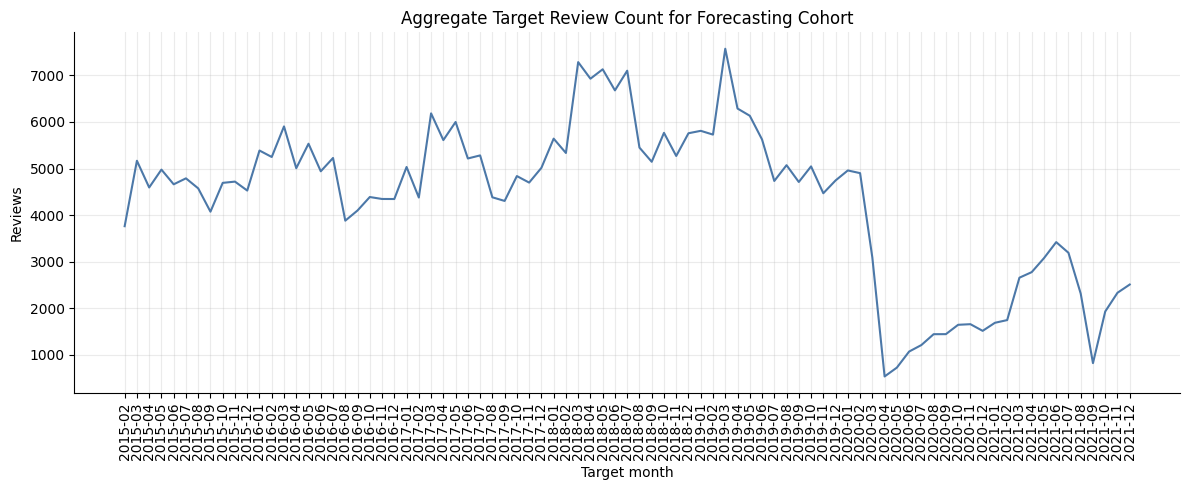

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\feature_engineering\cohort_monthly_target_reviews.png


In [10]:
monthly_target = modeling.groupby("target_month_str")["target_next_month_reviews"].sum()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_target.index, monthly_target.values, color="#4C78A8")
ax.set_title("Aggregate Target Review Count for Forecasting Cohort")
ax.set_xlabel("Target month")
ax.set_ylabel("Reviews")
ax.tick_params(axis="x", rotation=90)
fig.tight_layout()
path = FIGURES_DIR / "cohort_monthly_target_reviews.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

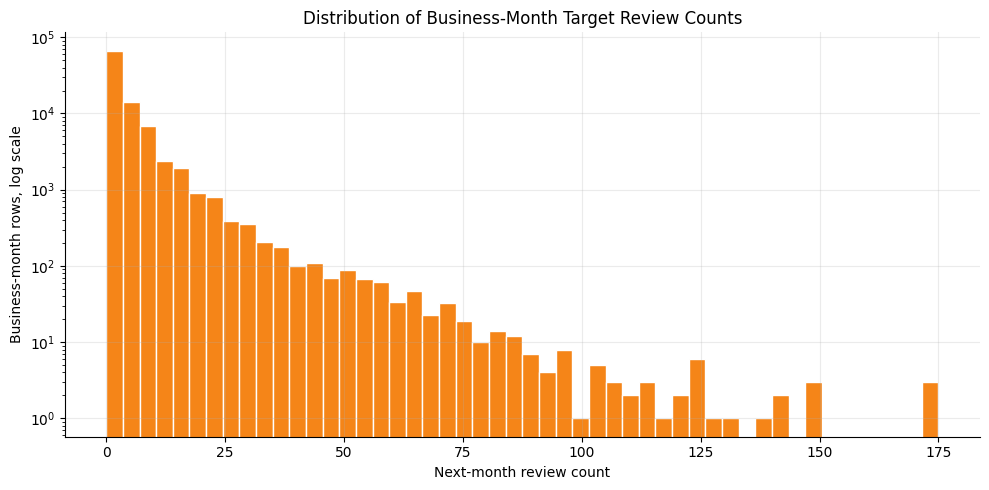

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\feature_engineering\target_review_count_distribution.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(modeling["target_next_month_reviews"], bins=50, color="#F58518", edgecolor="white")
ax.set_yscale("log")
ax.set_title("Distribution of Business-Month Target Review Counts")
ax.set_xlabel("Next-month review count")
ax.set_ylabel("Business-month rows, log scale")
fig.tight_layout()
path = FIGURES_DIR / "target_review_count_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

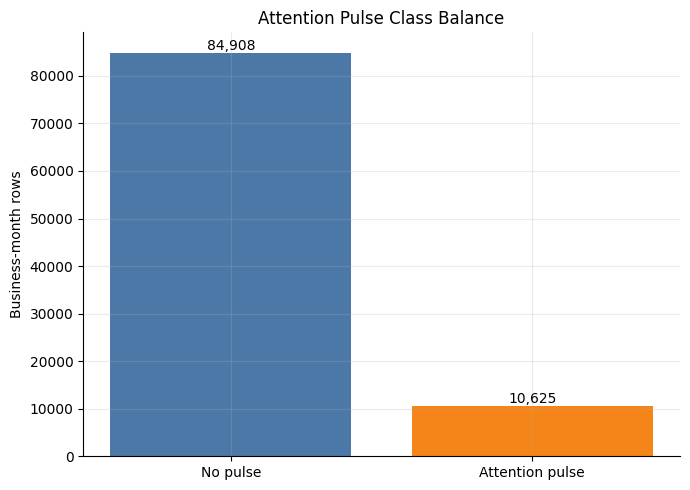

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\feature_engineering\attention_pulse_class_balance.png


In [12]:
pulse_counts = modeling["attention_pulse"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["No pulse", "Attention pulse"], [pulse_counts.get(0, 0), pulse_counts.get(1, 0)], color=["#4C78A8", "#F58518"])
ax.set_title("Attention Pulse Class Balance")
ax.set_ylabel("Business-month rows")
for index, value in enumerate([pulse_counts.get(0, 0), pulse_counts.get(1, 0)]):
    ax.text(index, value, f"{value:,}", ha="center", va="bottom")
fig.tight_layout()
path = FIGURES_DIR / "attention_pulse_class_balance.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

## Feature-Engineering Takeaways

- Final table: **95,533 business-month rows** and **1,151 active businesses**.
- Attention pulses flag unusual next-month review increases relative to each business's rolling 6-month baseline.
- NLP features use only reviews from the feature month and previous two months.
- SNA features describe recent reviewers as of the feature month.
- The saved figures document aggregate review activity, target skew, and attention-pulse class balance.